# 07_Serverless_CRUD_API_on_AWS

Here we’ll build a **serverless CRUD API** on AWS and understand all the services and options you see in the console.

CRUD = **Create, Read, Update, Delete**.

We will connect these AWS services:

* **API Gateway** – HTTP entry point for the outside world (your UI, Postman, etc.).
* **Lambda** – runs your Node.js code for each request.
* **DynamoDB** – NoSQL database for storing tasks.
* **CloudWatch** – logs + metrics (debugging and monitoring).
* **IAM** – Identity and Access Management (permissions & roles).

High‑level flow:

1. Client (browser / Postman / mobile) sends HTTP request to **API Gateway**.
2. API Gateway forwards the request to a **Lambda function**.
3. The Lambda function, using its **IAM role**, reads/writes data in **DynamoDB** and writes logs to **CloudWatch Logs**.
4. Lambda returns a response to **API Gateway**, which returns it to the client.

---

## 1. Create DynamoDB Table (tasks)

### 1.1 Open DynamoDB and create table

1. In AWS Console search for **“DynamoDB”**.
2. Go to **Tables → Create table**.
3. **Table name**: `tasks`
   This is just a logical name for your collection.
4. **Partition key**: `id` (String)

   * In DynamoDB, the **partition key** is the primary identifier for each item.
   * It determines **where** the item is stored internally (how it is partitioned).
   * In our app, this `id` will be a unique ID for each task.
5. Leave all other options as **default** for this tutorial (capacity, encryption, PITR, etc.).
6. Click **Create table**.

### 1.2 Important table options (what they mean)

Even though we left them as default, you should know what they do:

* **Table settings (Capacity mode)**

  * **On‑demand** – You pay per request. Scales automatically. Great for unpredictable traffic.
  * **Provisioned** – You specify read/write capacity units (RCUs/WCUs). Cheaper at predictable scale but more work.

* **Read/write capacity** (only if you choose Provisioned):

  * RCUs = how many strongly‑consistent reads per second.
  * WCUs = how many writes per second.

* **Auto scaling** – Dynamically adjusts RCUs/WCUs to match load.

* **Table class**

  * Standard vs Standard‑IA (infrequent access) for cost optimization.

* **Encryption at rest** – KMS‑based encryption of data; enabled by default.

For this demo, defaults are enough.

### 1.3 Explore table items

After the table is **ACTIVE**:

* Click the table `tasks` → **Explore table items**.
* At first it will be empty.
* Later you’ll see the JSON items Lambda inserts/updates/deletes.

---

## 2. Create Lambda Function (taskCrudHandler)

We’ll create a single Lambda with handlers for **GET, POST, PATCH, DELETE**.

### 2.1 Open Lambda and create function

1. In AWS Console, search for **“Lambda”**.
2. Click **Create function**.

You will see three options (like in the screenshots):

* **Author from scratch**
  Start with an empty Lambda and write/upload your own code. This is what we use.

* **Use a blueprint**
  Prebuilt templates for common integrations (e.g., S3 triggers, basic REST API). Good for beginners.

* **Container image**
  Use a Docker image from ECR as the Lambda code (for custom runtimes or complex dependencies).

Select **Author from scratch**.

### 2.2 Basic configuration

* **Function name**: `taskCrudHandler`
  (Any name is fine, but descriptive names help.)

* **Runtime**: choose **Node.js** runtime that matches your code (e.g., `Node.js 20.x`).
  Runtime = language + version in which your handler will run.

* **Architecture**:

  * `x86_64` – Traditional Intel/AMD architecture.
  * `arm64` – Graviton (often cheaper and faster, but some native binaries may differ).
  * For most simple apps, either is fine; default is OK.

* **Permissions** (Execution role section at the bottom):

  * Choose **Create a new role with basic Lambda permissions**.
  * This automatically creates an **IAM role** with policy:

    * `AWSLambdaBasicExecutionRole` → allows writing logs to **CloudWatch Logs**.

Click **Create function**.

Now AWS creates the Lambda and sends you to:

* **Function overview** (top) – shows triggers, function ARN, etc.
* **Code** tab – inline editor and Deploy button.
* **Configuration** tab – environment, permissions, timeout, memory, etc.

* We edit this function to,



```json
import { ListTablesCommand, DynamoDBClient } from "@aws-sdk/client-dynamodb";
import {
  UpdateCommand,
  PutCommand,
  DynamoDBDocumentClient,
  ScanCommand,
  DeleteCommand,
} from "@aws-sdk/lib-dynamodb";

const client = new DynamoDBClient();
const docClient = DynamoDBDocumentClient.from(client);

export const handler = async (event, context) => {
  let response;

  switch (event.httpMethod) {
    case "GET":
      response = await handleGetRequest();
      break;
    case "POST":
      response = await handlePostRequest(event, context);
      break;
    case "PATCH":
      response = await handlePatchRequest(event);
      break;
    case "DELETE":
      response = await handleDeleteRequest(event);
      break;
    default:
      response = {
        statusCode: 400,
        body: JSON.stringify({
          message: "Invalid request type",
          event: event,
          context: context,
        }),
      };
  }

  return response;
};

const handleGetRequest = async () => {
  const command = new ScanCommand({
    TableName: "tasks",
  });

  const response = await docClient.send(command);

  return {
    statusCode: 200,
    body: JSON.stringify(response.Items),
  };
};

const handlePostRequest = async (event, context) => {
  const { name, completed } = JSON.parse(event.body);

  const command = new PutCommand({
    TableName: "tasks",
    Item: {
      id: context.awsRequestId,
      name,
      completed,
    },
  });

  await docClient.send(command);

  return {
    statusCode: 200,
    body: JSON.stringify({ message: "Task created successfully" }),
  };
};

export const handlePatchRequest = async (event, context) => {
  const { id, name, completed } = JSON.parse(event.body);

  const command = new UpdateCommand({
    TableName: "tasks",
    Key: {
      id,
    },
    ExpressionAttributeNames: {
      "#name": "name",
    },
    UpdateExpression: "set #name = :n, completed = :c",
    ExpressionAttributeValues: {
      ":n": name,
      ":c": completed,
    },
    ReturnValues: "ALL_NEW",
  });

  const response = await docClient.send(command);

  return {
    statusCode: 200,
    body: JSON.stringify({
      message: "Task updated successfully",
      task: response.Attributes,
    }),
  };
};

const handleDeleteRequest = async (event) => {
  const { id } = JSON.parse(event.body);

  const command = new DeleteCommand({
    TableName: "tasks",
    Key: { id },
    ReturnValues: "ALL_OLD",
  });

  const response = await docClient.send(command);

  return {
    statusCode: 200,
    body: JSON.stringify({
      message: "Task deleted successfully",
      task: response.Attributes,
    }),
  };
};
```

---

## 3. Grant Lambda Permissions (IAM Role & Policies)

Our Lambda must be allowed to:

1. Read/write to **DynamoDB** table `tasks`.
2. Write logs to **CloudWatch Logs** (already covered by basic execution role).

### 3.1 Open the Lambda’s execution role

1. In the Lambda page, go to **Configuration → Permissions**.
2. Under **Execution role**, click the **Role name** (blue link).
   This opens the **IAM** console on that role.

You’ll see:

* **Trusted entities**: `lambda.amazonaws.com` (services allowed to assume this role).
* **Permissions policies**: currently **AWSLambdaBasicExecutionRole** (CloudWatch logging).

### 3.2 Attach policies for DynamoDB and CloudWatch Logs

1. In the role view, click **Add permissions → Attach policies**.
2. Search for:

   * `AmazonDynamoDBFullAccess` – Grants full access (read/write, list, update) to all DynamoDB tables in the account.
   * `CloudWatchLogsFullAccess` – Grants full access to CloudWatch Logs.
3. Check both policies and click **Add permissions**.

> ⚠️ In production you would normally create **least‑privilege policies** (e.g., DynamoDB access only to the `tasks` table). But for learning, full‑access policies are simpler.

Now your Lambda can:

* Scan, put, update, delete items in `tasks` table.
* Write detailed logs to CloudWatch.

---

## 4. Add CRUD Code to Lambda

On the **Code** tab of your Lambda:

1. Paste the Node.js code from the GitHub repo (or your own implementation) that:

   * Imports `AWS SDK` or `@aws-sdk/client-dynamodb`.
   * Creates handlers for:

     * **GET** → scan all tasks.
     * **POST** → create a new task (put item).
     * **PATCH** → update task.
     * **DELETE** → delete task.
2. Ensure the **handler** setting matches your file & function name (e.g., `index.handler`).
3. Click **Deploy** to save the new version.

Under the hood:

* Each time Lambda is invoked, AWS spins up (or reuses) a **runtime environment**.
* Your handler function receives:

  * `event` – contains HTTP method, path, body, headers (when using proxy integration).
  * `context` – metadata about the invocation.
* Your code uses the IAM role to call DynamoDB.
* Logs (`console.log`) are automatically written to **CloudWatch Logs**.

---

## 5. Create REST API in API Gateway

Now we expose the Lambda via HTTP endpoints.

### 5.1 Create REST API

1. In AWS Console, search for **“API Gateway”**.

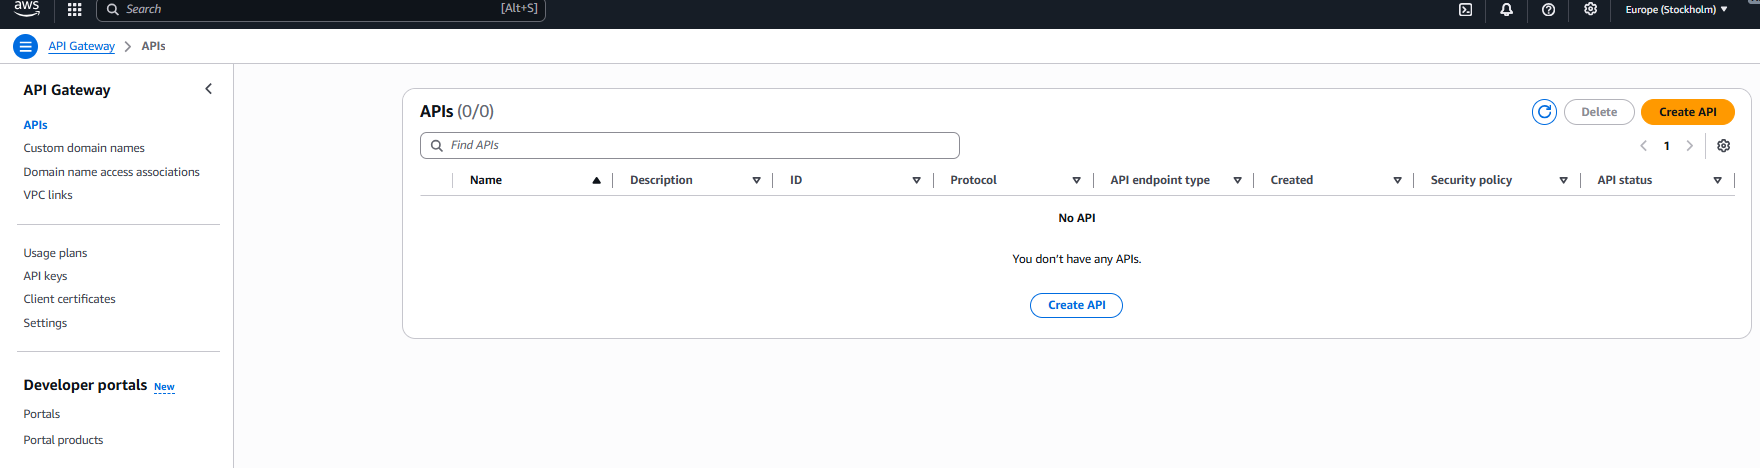

2. Choose **REST API** (not HTTP API) → click **Build**.

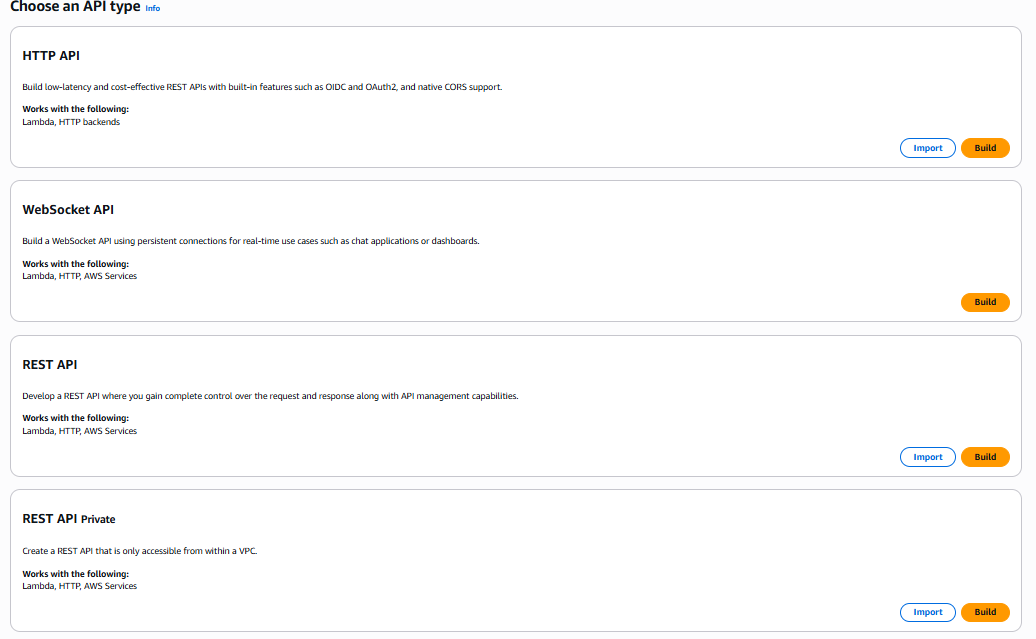

3. **API name**: `task-api`.

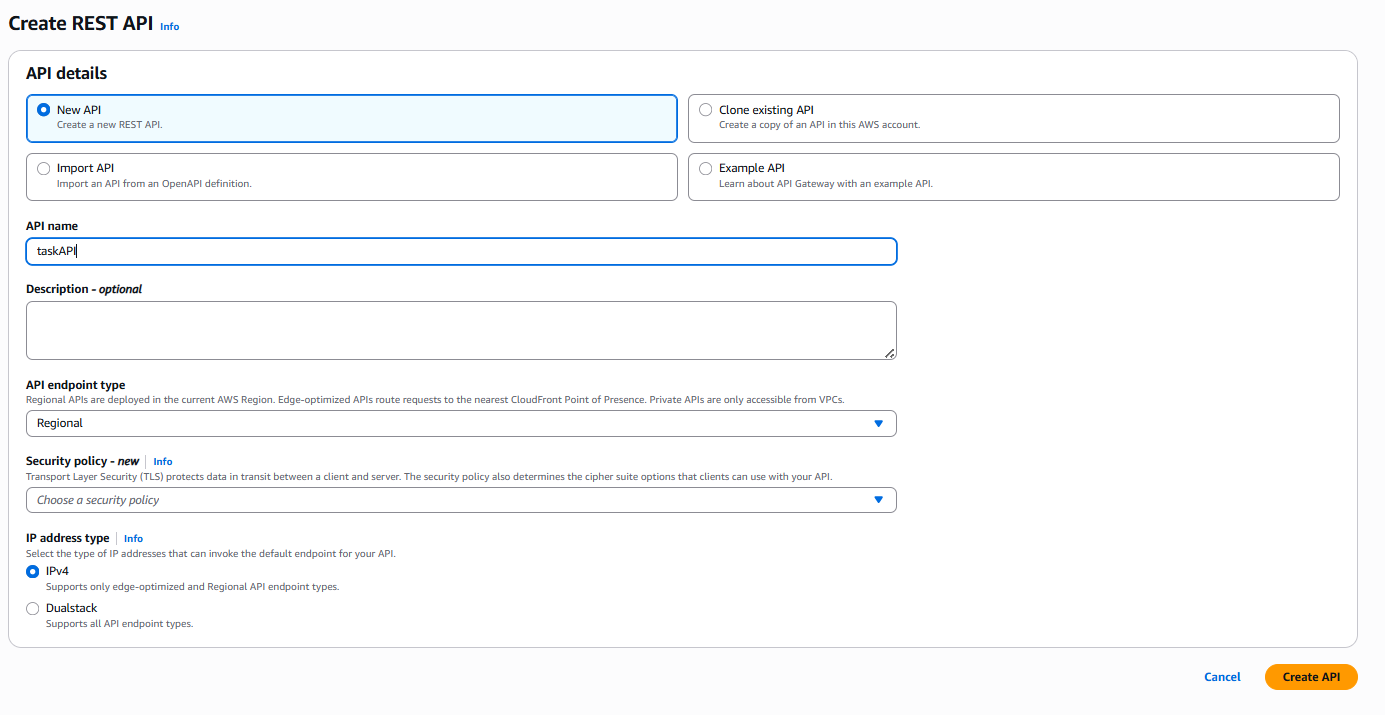

4. **Endpoint type** (for classic REST API):

   * **Regional** (default): good for most apps.
   * **Edge‑optimized**: fronted by CloudFront for global clients.
   * **Private**: for VPC‑internal use.

5. Add Security Policy.

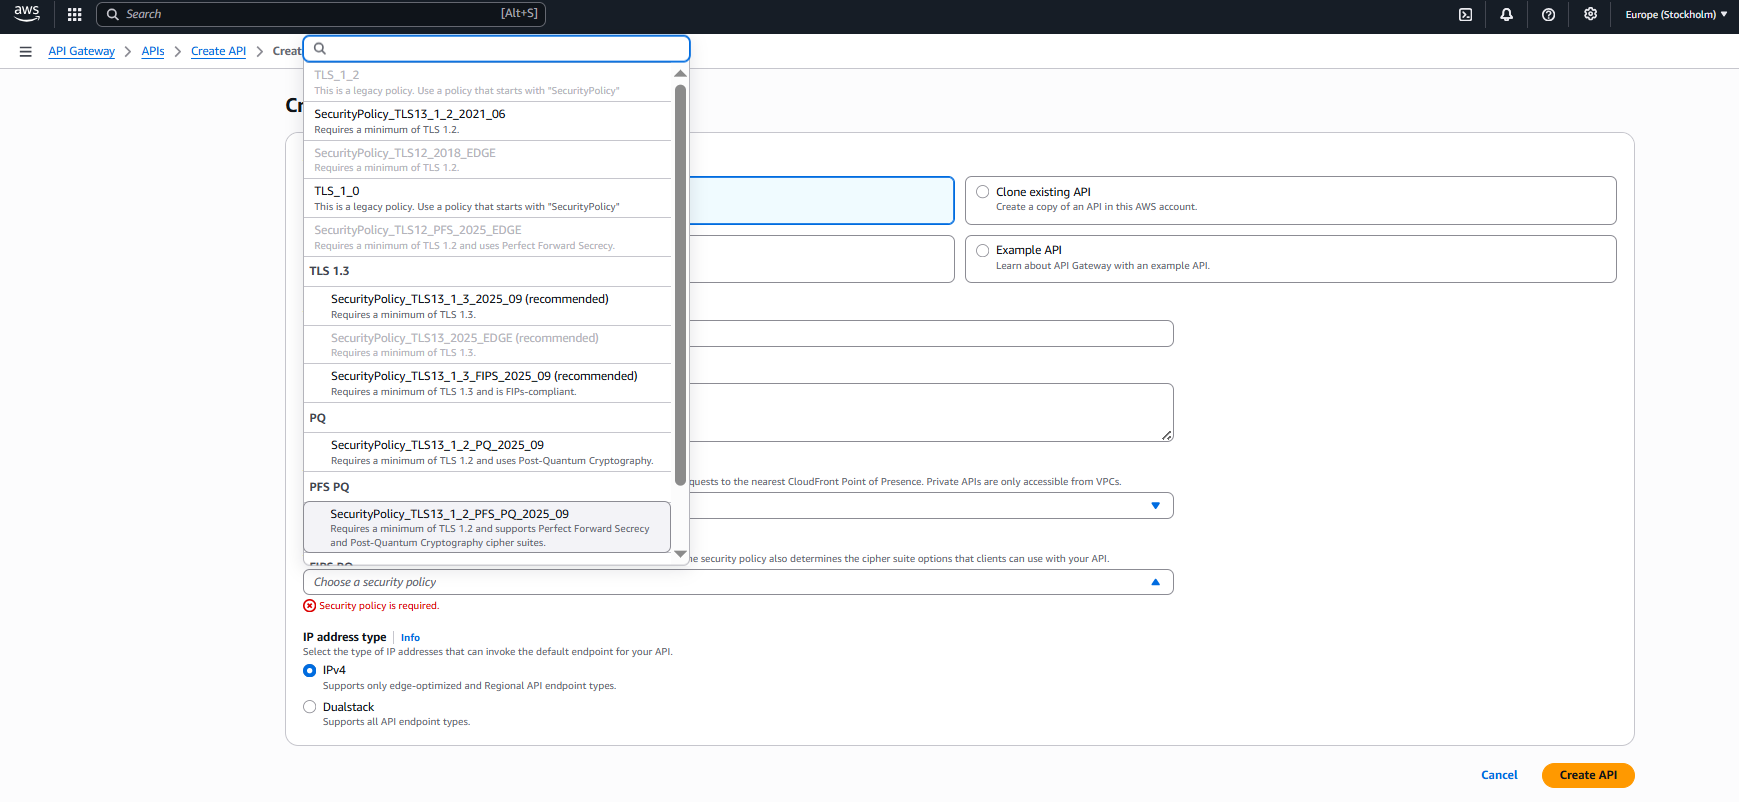
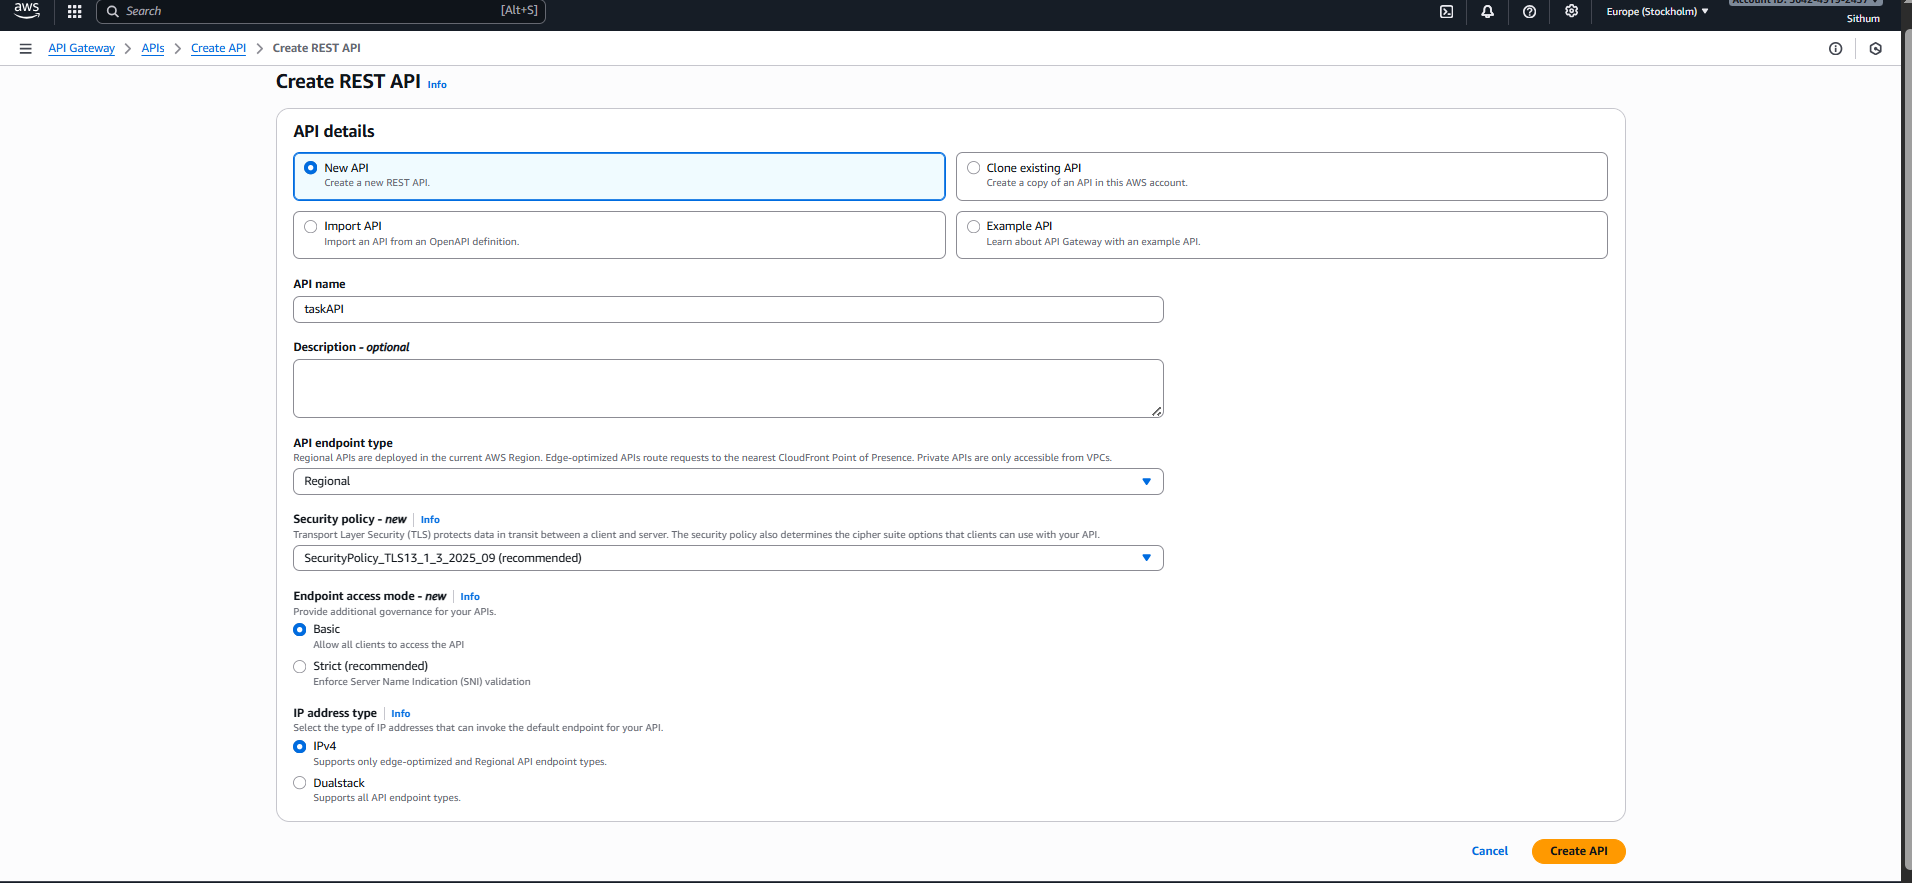

6. Keep **New API** selected.
7. Click **Create API**.

### 5.2 Create a Resource `/task`

1. In the left tree, select the root `/`.

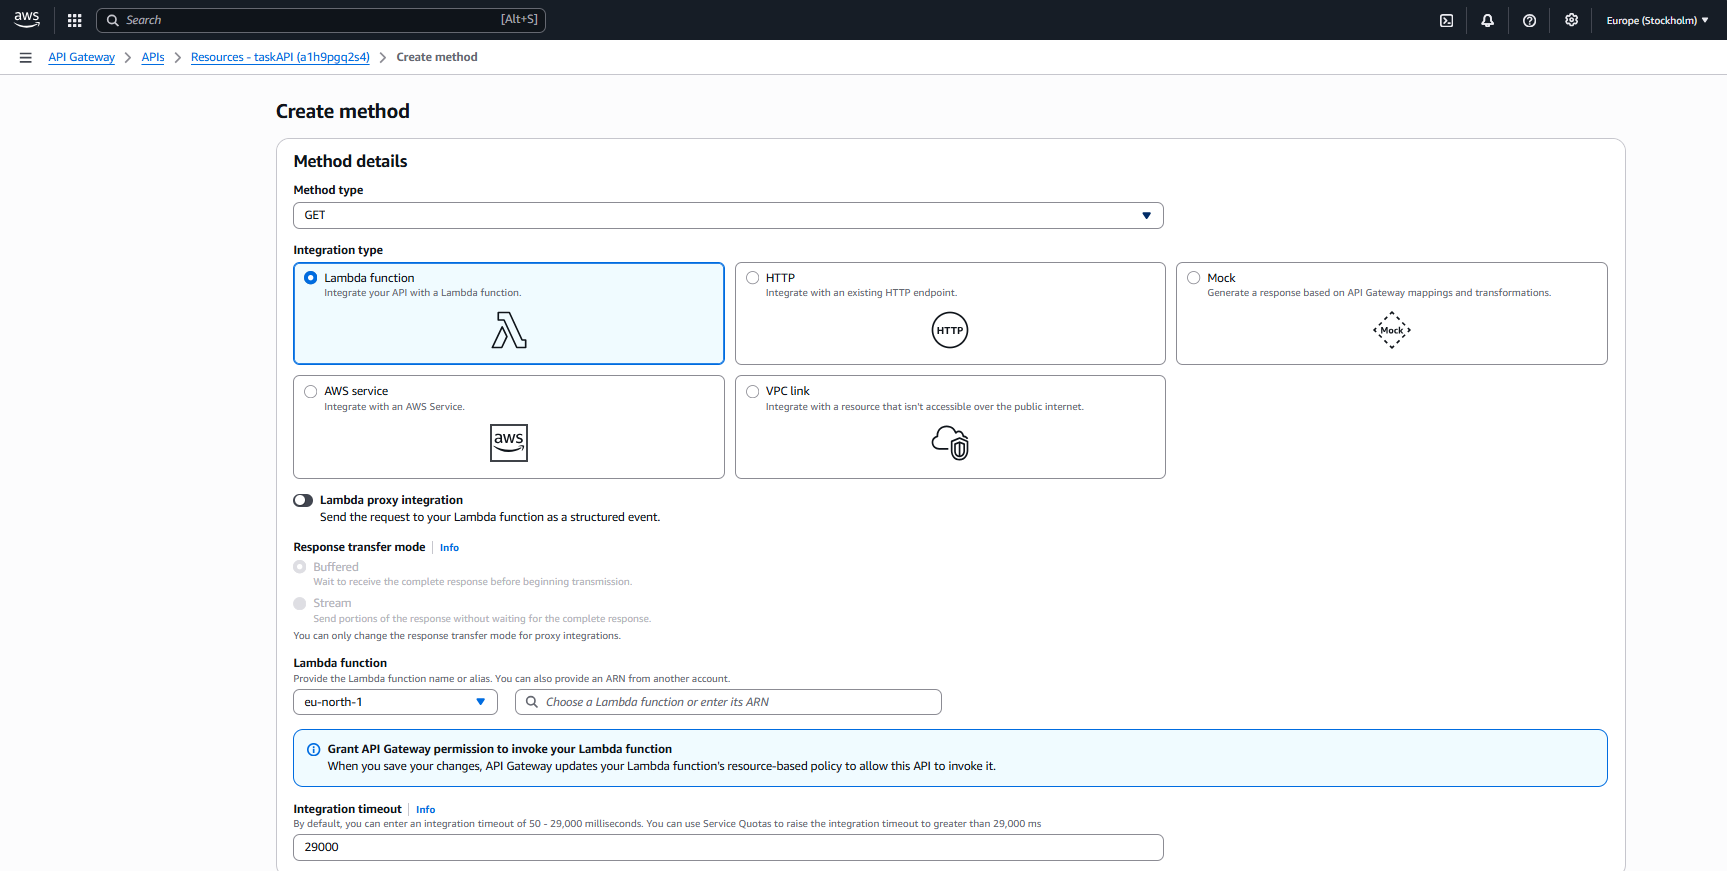

2. Click **Actions → Create Resource**.
3. **Resource Name**: `task`.
4. **Resource Path**: `/task` (auto‑filled).
5. Check **Enable CORS**.
6. Click **Create Resource**.

**What is CORS?**

* Cross‑Origin Resource Sharing – controls which browsers/hosts can call your API.
* Enabling CORS makes API Gateway automatically add headers like:

  * `Access-Control-Allow-Origin: *`
  * `Access-Control-Allow-Methods: GET, POST, ...`
* Required if your frontend (e.g., `http://localhost:3000`) is on a different origin than API Gateway.

### 5.3 Create Methods (GET, POST, PATCH, DELETE)

We want all HTTP methods under `/task` to invoke the **same Lambda**.

For each method:

1. Select the `/task` resource.
2. Click **Actions → Create Method**.
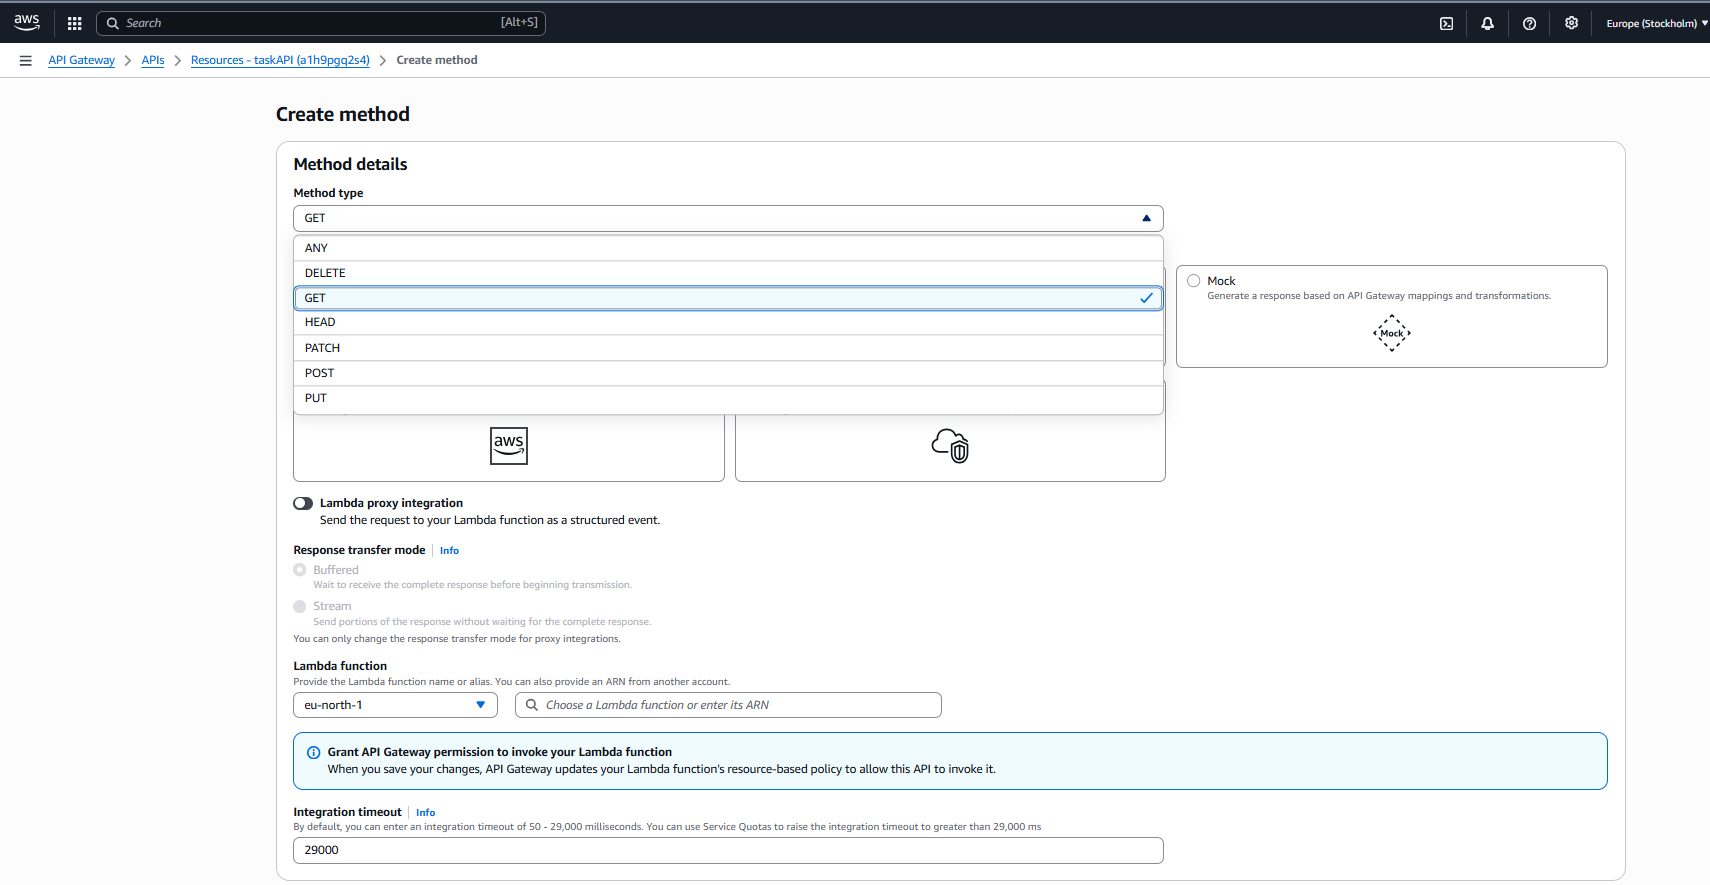

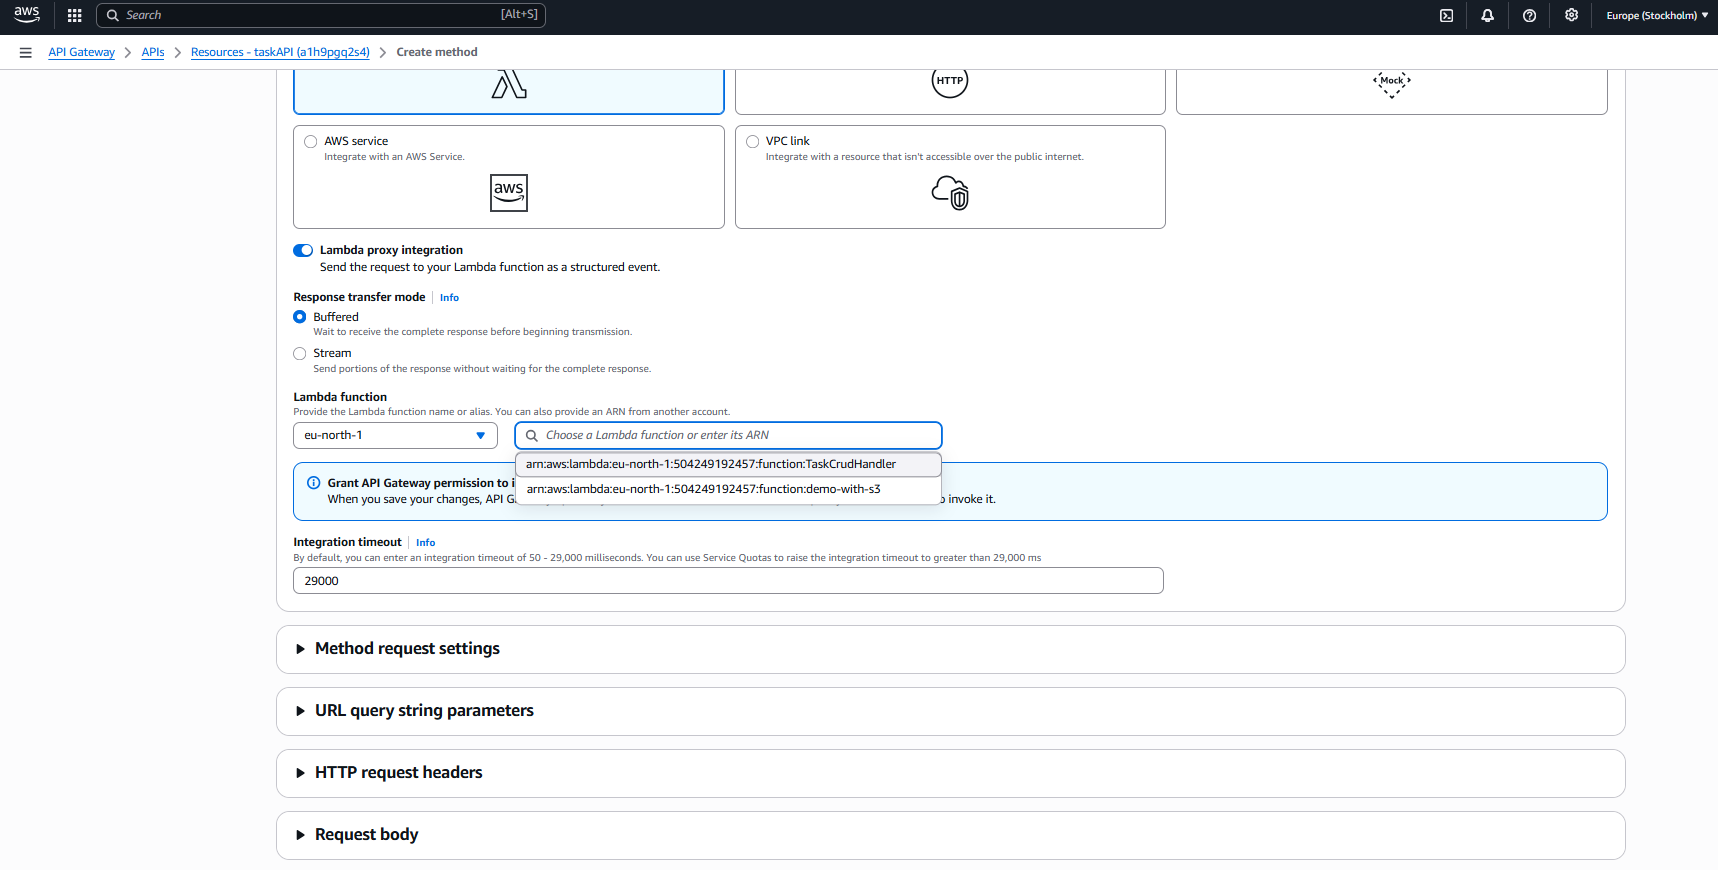

4. Pick method type (GET / POST / PATCH / DELETE) and click ✔.
5. Configure method:

   * **Integration type**: `Lambda Function`.
   * **Use Lambda Proxy integration**: **✔ enabled**.
   * **Lambda Region**: same region as your Lambda.
   * **Lambda Function**: `taskCrudHandler` (start typing to find it).
6. Click **Save**.

Repeat for **GET, POST, PATCH, DELETE**.

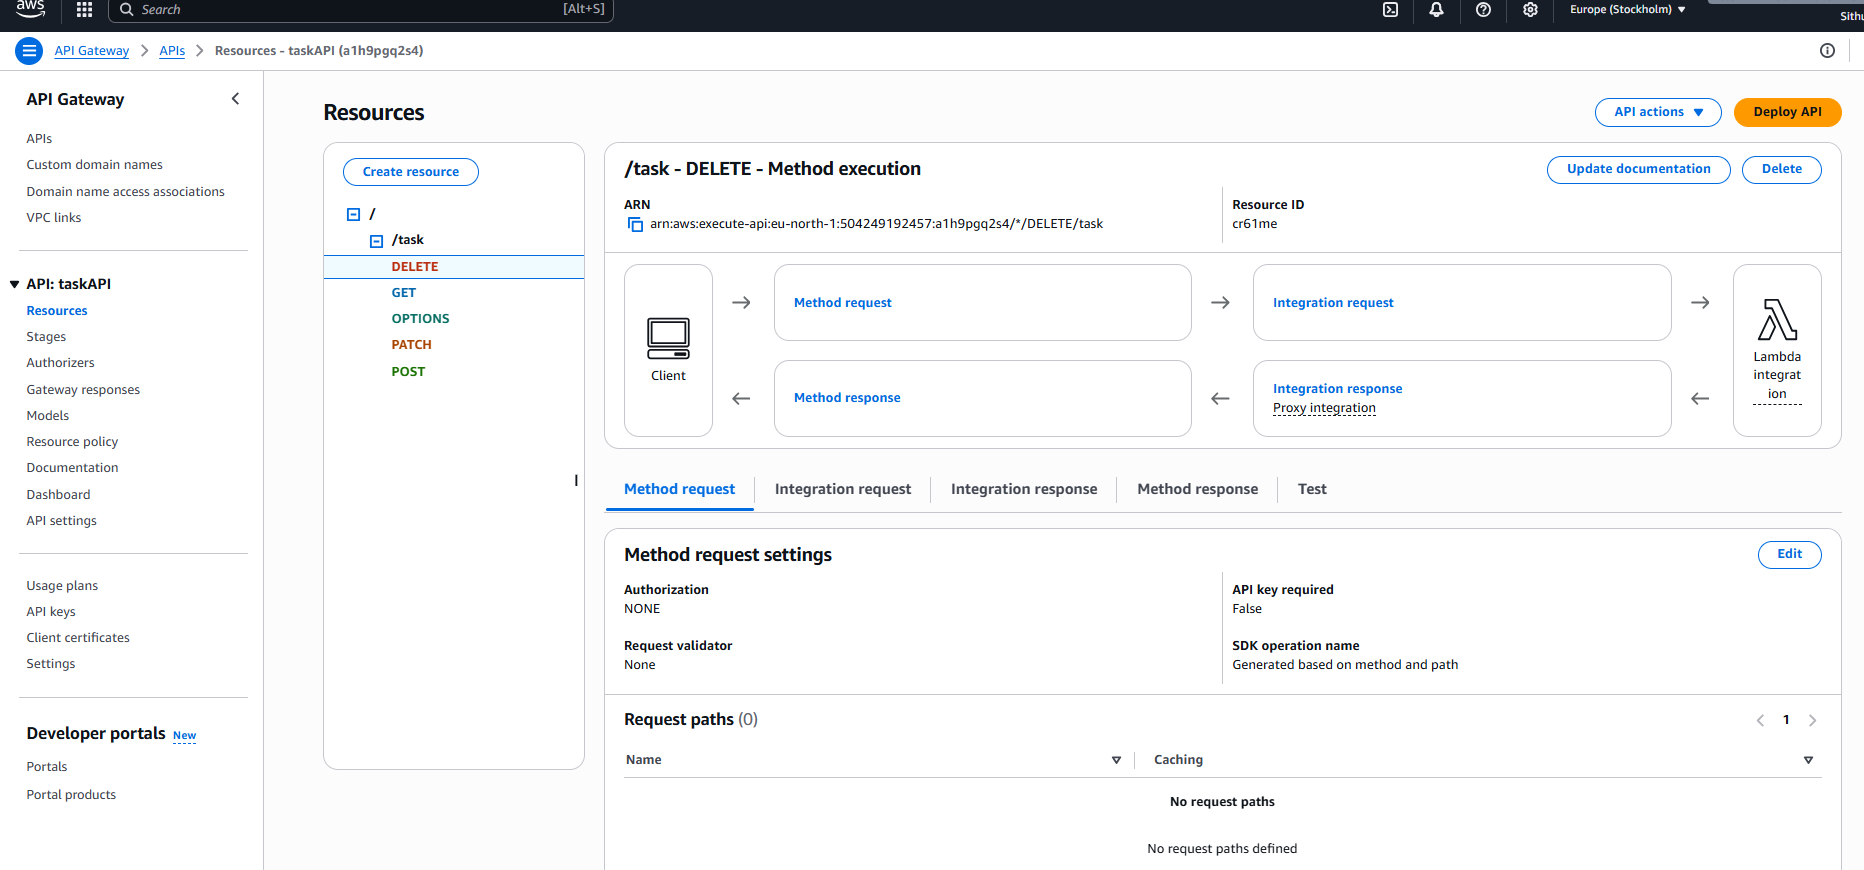

#### What is “Lambda Proxy Integration”?

* When **enabled**, API Gateway passes the full HTTP request to Lambda as a single `event` object:

  * `event.httpMethod` – HTTP verb.
  * `event.path` – request path.
  * `event.headers` – all headers.
  * `event.body` – raw body string.
* Lambda returns an object: `{ statusCode, headers, body }`.
* This gives your Lambda complete control over the HTTP response.

If it were **disabled**, you’d have to manually map request parameters/body/headers to integration request fields.

---

## 6. Deploy the API (create a Stage)

Creating methods isn’t enough; you must **deploy** the API.

1. In API Gateway console, click **Actions → Deploy API**.

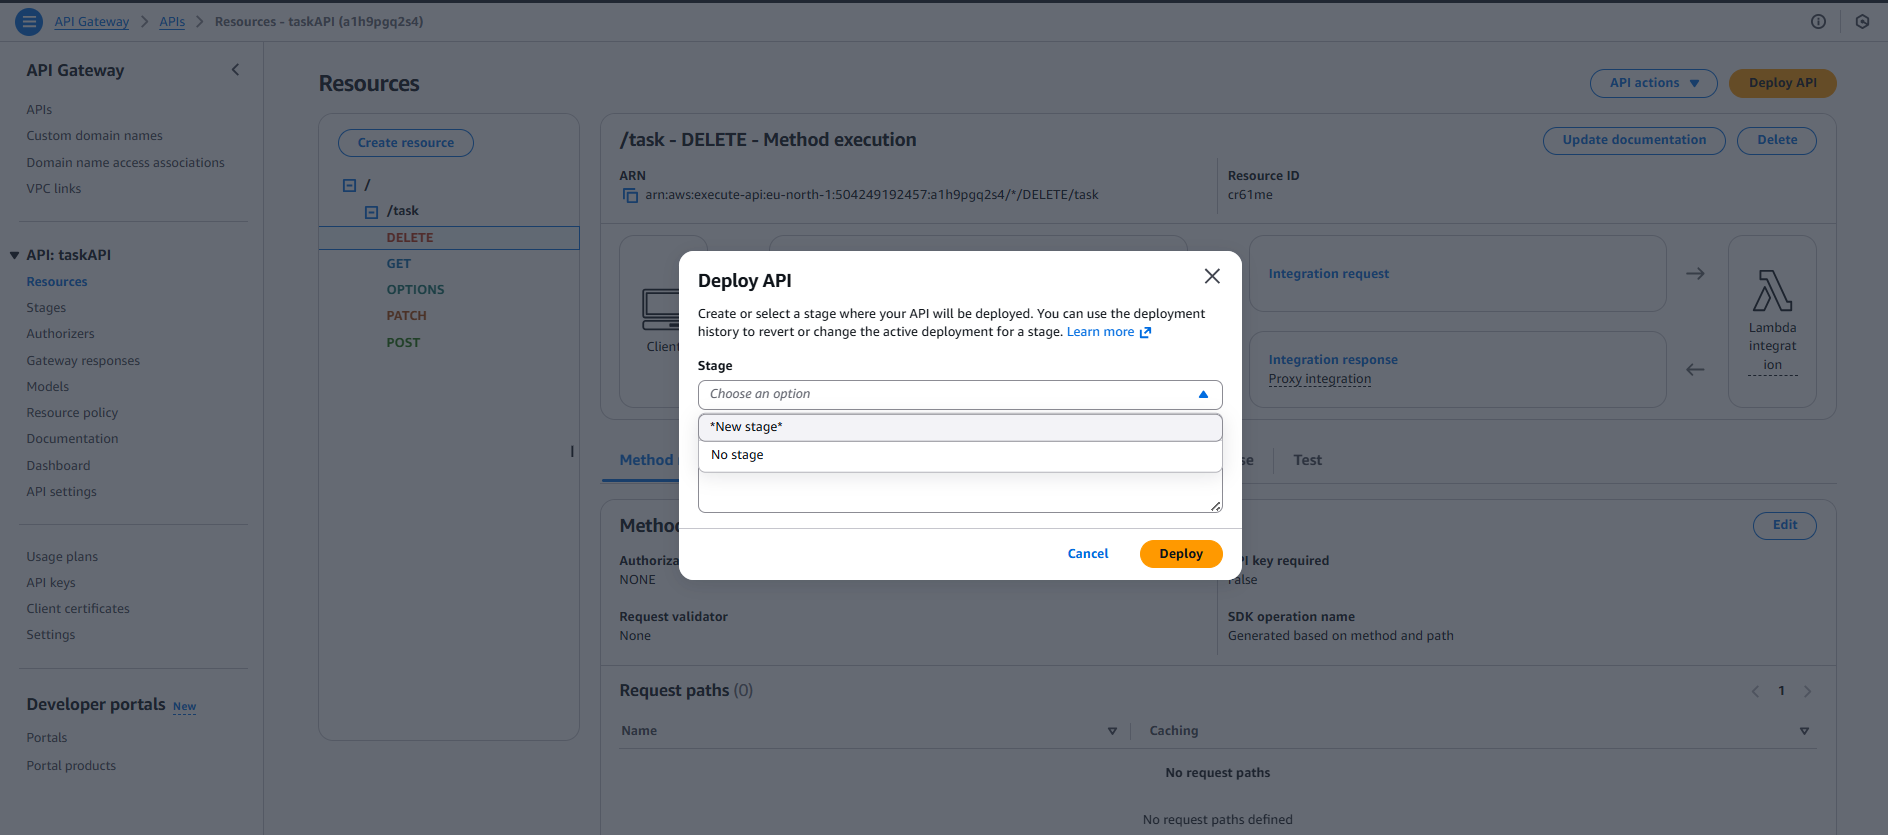

2. **Deployment stage**: choose **[New Stage]**.

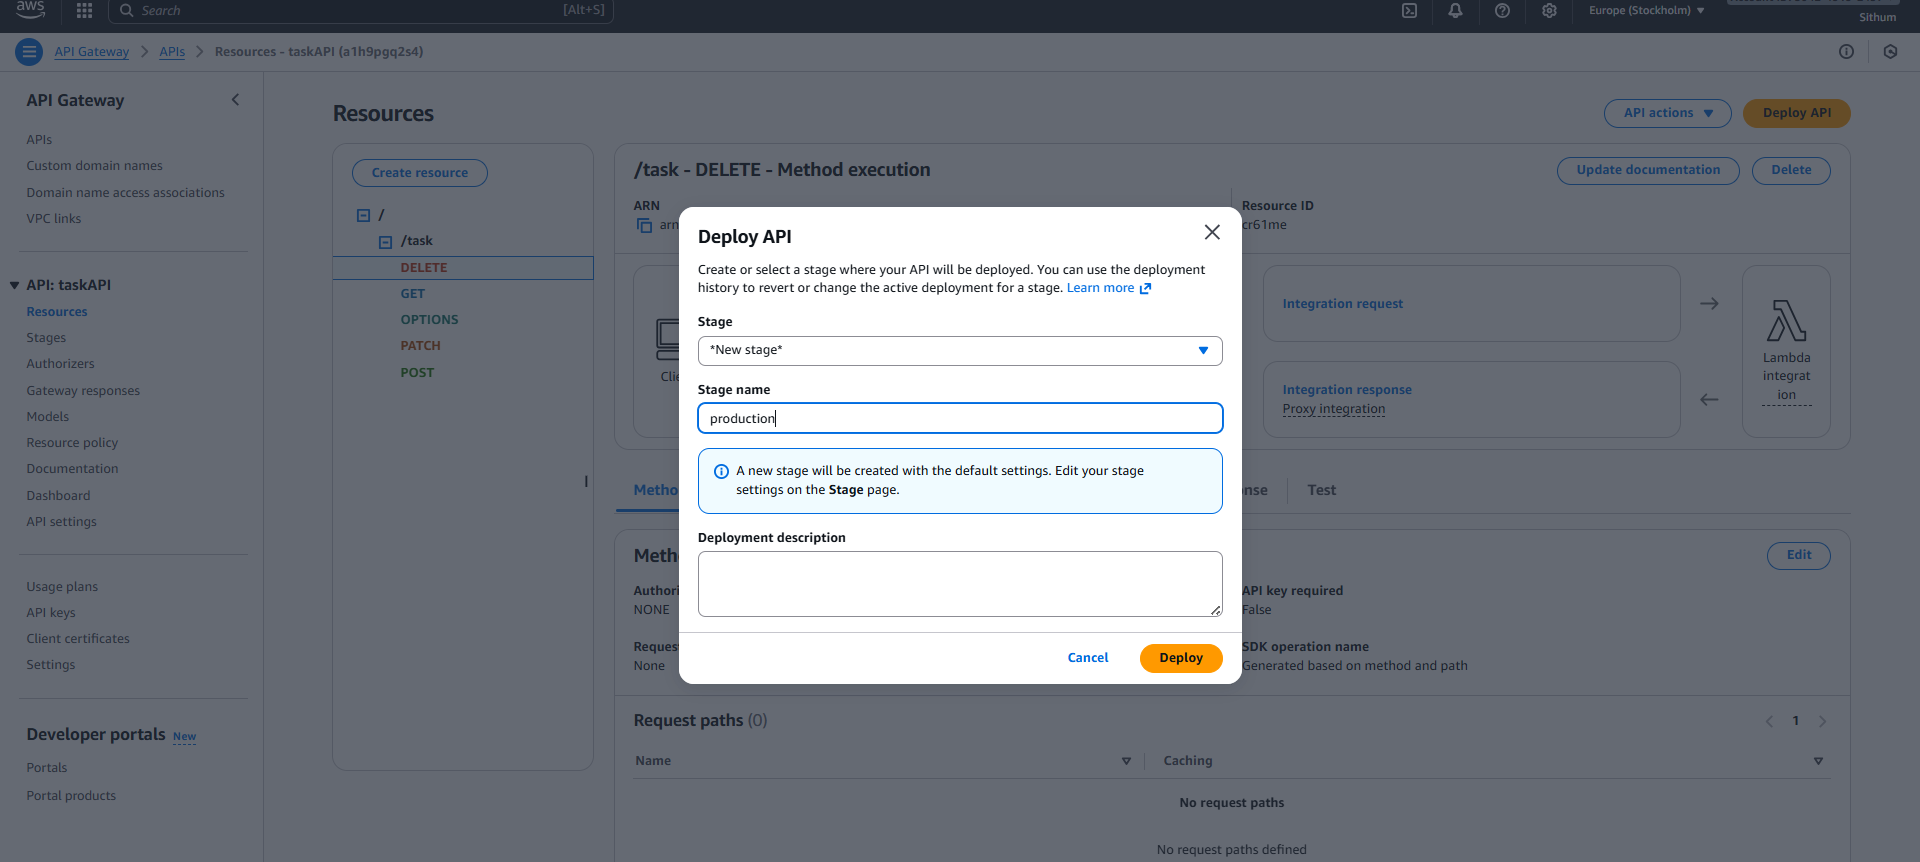

3. **Stage name**: `prod` or `production`.
4. Optionally add **Stage description** and **Deployment description**.
5. Click **Deploy**.

Now you get a **Stage Editor** view for `production` with:

* **Invoke URL**: e.g., `https://abc123.execute-api.region.amazonaws.com/production`.
* Under it, your **resources & methods**: `/task` with GET/POST/PATCH/DELETE.

The full URL for `/task` GET is:
`{Invoke URL}/task`  (e.g., `https://abc123.execute-api.us-east-1.amazonaws.com/production/task`).

---

## 7. Test API with Postman (CRUD)

Use **Postman** (or curl / Thunder Client) to test each operation.

### 7.1 GET – Read all tasks


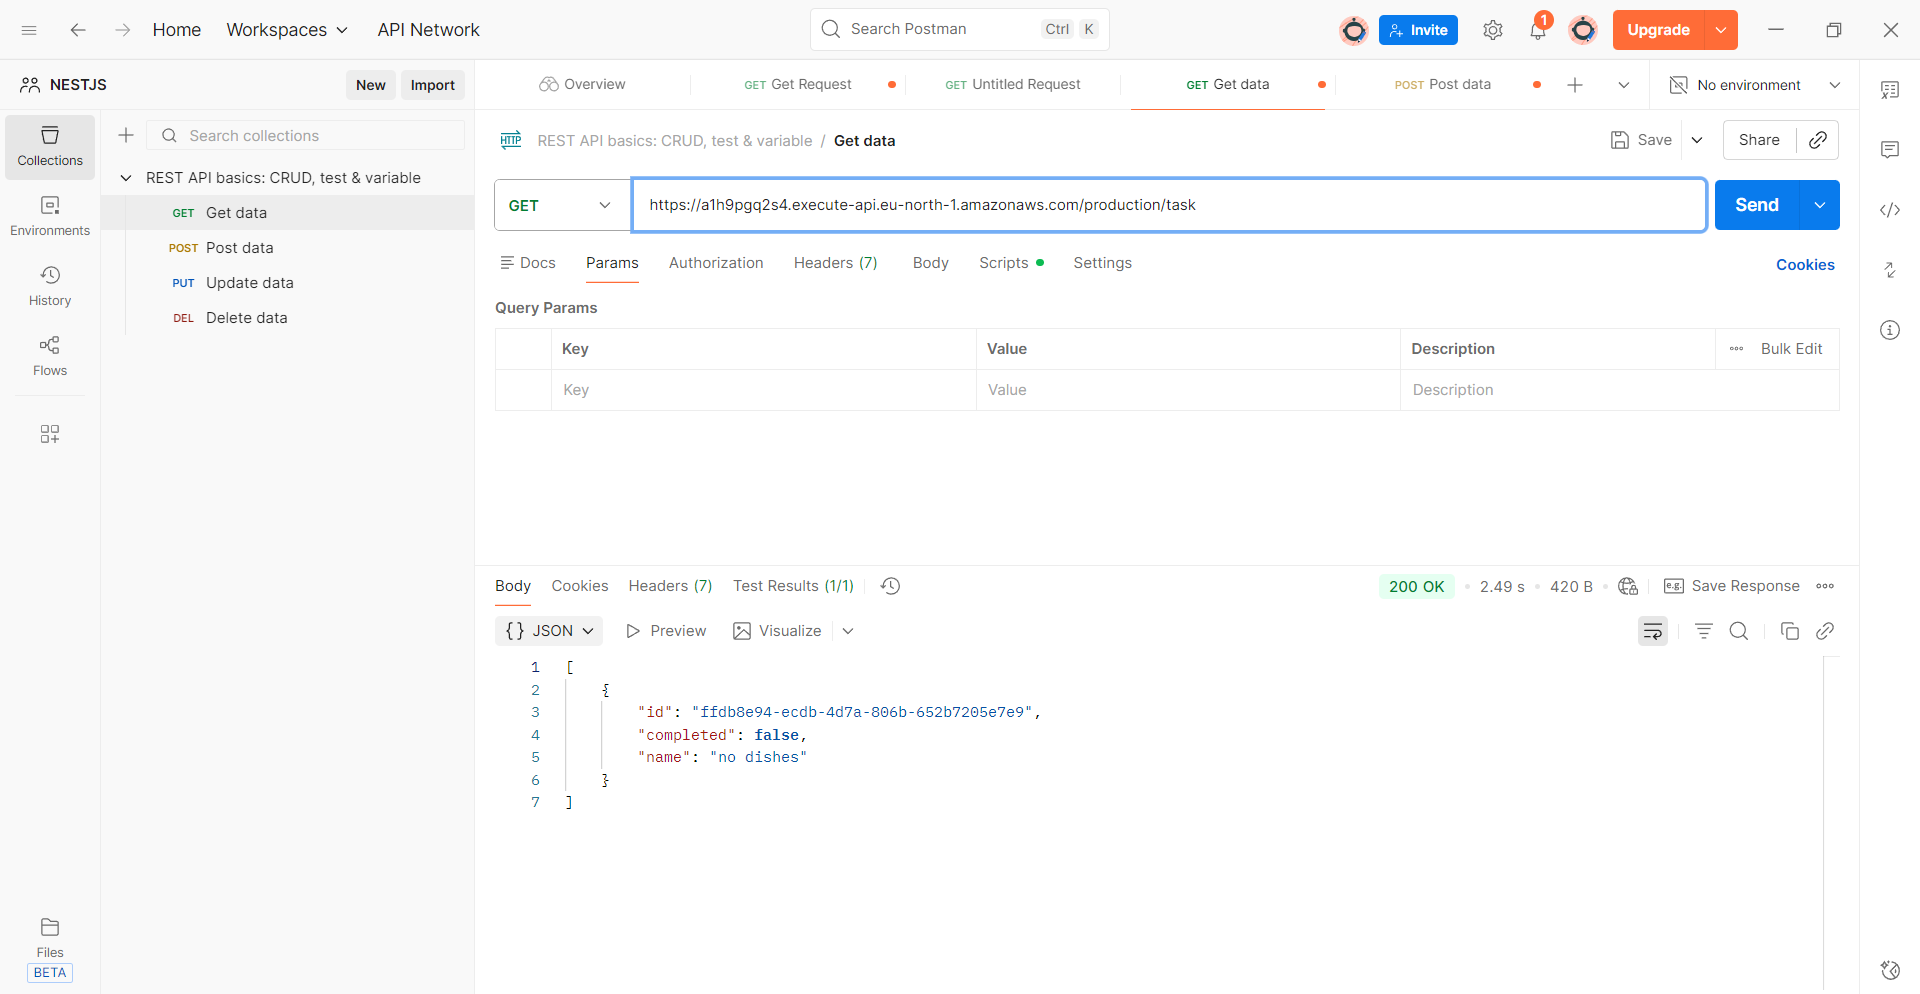

* Method: **GET**
* URL: `https://.../production/task`
* Expected response initially: `[]` (empty array).

### 7.2 POST – Create a task

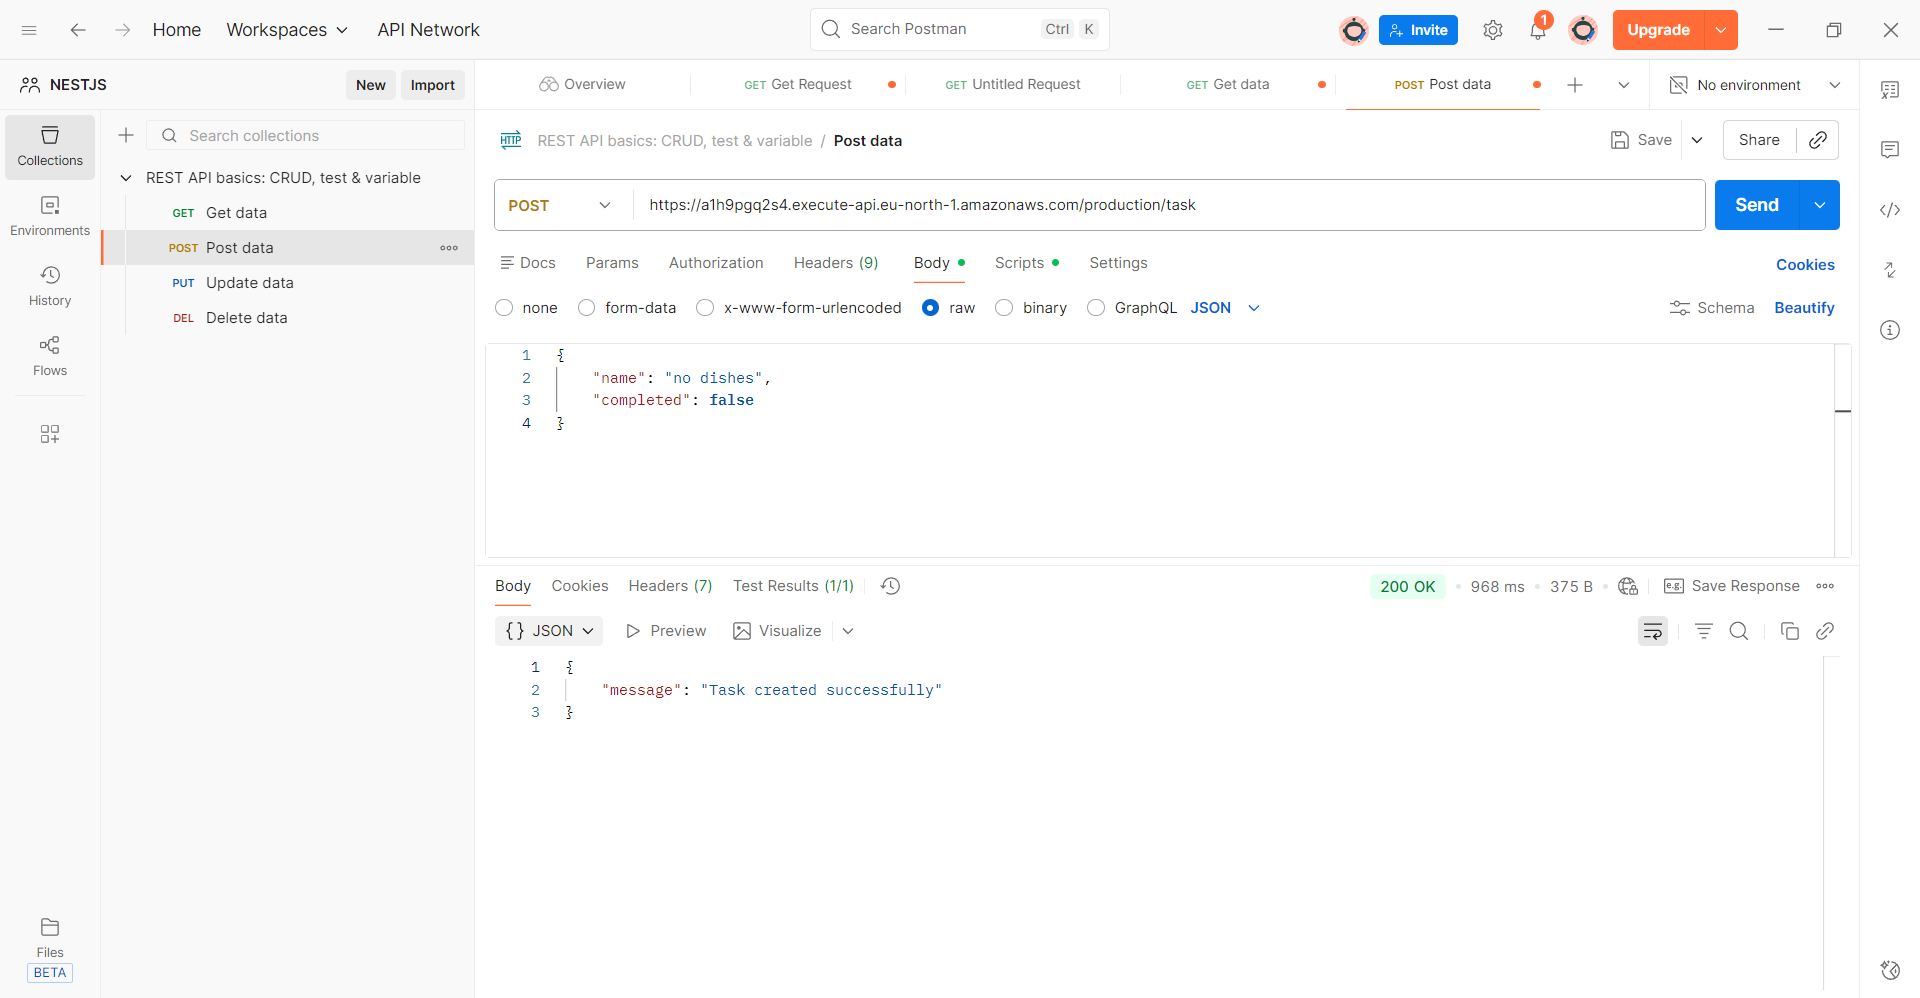

* Method: **POST**
* URL: same as above.
* Headers:

  * `Content-Type: application/json`
* Body (raw JSON), for example:

```json
{
  "name": "Clean room",
  "completed": false
}
```

Expected response: `task created successfully` and the created task object.

Check DynamoDB:

* Go back to **DynamoDB → Tables → tasks → Explore table items**.
* You will see a new item with `id`, `name`, `completed`.

### 7.3 PATCH – Update a task

* First, copy the `id` value of the existing task from DynamoDB.
* In Postman:

  * Method: **PATCH**
  * URL: same `/task` URL.
  * Body (example):

```json
{
  "id": "<PASTE_ID_HERE>",
  "name": "Wash car",
  "completed": true
}
```

Expected response: `updated successfully` and the updated task.

Refresh DynamoDB items → you should see the updated fields.

### 7.4 DELETE – Delete a task

* Method: **DELETE**
* URL: same `/task` URL.
* Body:

```json
{
  "id": "<PASTE_ID_HERE>"
}
```

Expected response: `task successfully deleted` and the deleted task data.

Check DynamoDB again → table is empty.

---

## 8. Debugging with CloudWatch Logs

Now we’ll see how **CloudWatch** helps when things go wrong.

### 8.1 Introduce an intentional error in Lambda

1. Go to your Lambda **Code** tab.
2. Add some invalid code in the GET handler (e.g., use a variable before it’s defined).
3. Click **Deploy**.

### 8.2 Trigger the error

* In Postman, send a **GET** request to `/task` again.
* Response: **500 Internal Server Error**.
* But the body doesn’t show what exactly went wrong.

### 8.3 View logs in CloudWatch

1. In AWS Console, search for **“CloudWatch”**.
2. Go to **Logs → Log groups**.
3. Find log group named like:
   `/aws/lambda/taskCrudHandler`.
4. Click it → you’ll see **Log streams** (each is a sequence of logs for a Lambda container).
5. Open the newest log stream at the top.
6. You’ll see:

   * `START` / `END` / `REPORT` lines for each invocation.
   * Your `console.log` outputs.
   * The **error stack trace** (e.g., `ReferenceError: cannot access 'v' before initialization`).

Use these logs to:

* Understand what part of the handler failed.
* See the incoming event payloads.
* Measure performance (duration, memory used, etc.).

Fix your code in Lambda, **Deploy** again, and then retest with Postman.

---

## 9. Recap: How Everything Works Together

* **DynamoDB** – stores `tasks` (id, name, completed, etc.). No schema definition needed (NoSQL).
* **Lambda (taskCrudHandler)** – contains logic for GET/POST/PATCH/DELETE, reads and writes to DynamoDB.
* **IAM Role** – gives Lambda permission to access DynamoDB & write logs to CloudWatch.
* **API Gateway (REST API)** – exposes `/task` endpoint. Each method invokes the same Lambda with **Lambda proxy integration**.
* **CloudWatch Logs** – records all Lambda logs and errors for debugging.

End result: you have a **fully serverless CRUD API**:

* No servers to manage.
* Scales automatically with traffic.
* You pay only for requests + Lambda execution time + DynamoDB usage.

---